# 00 · Data Audit

Verify the panel is fully simulated and describe key dimensions before any analysis.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel  = pd.read_parquet(DATA_DIR / "ship_month_panel.parquet")
events = pd.read_csv(DATA_DIR / "category_change_events.csv", parse_dates=["event_month"])

print(f"Panel: {panel.shape}  |  Events: {len(events)}")

Panel: (38400, 15)  |  Events: 144


## 1 · Simulated flag

In [2]:
assert panel["is_simulated"].all(), "Found non-simulated rows — abort!"
print("✓ All rows are simulated (is_simulated=True)")

✓ All rows are simulated (is_simulated=True)


## 2 · Panel dimensions

In [3]:
n_ships  = panel["ship_id"].nunique()
n_months = panel["month"].nunique()
date_min = panel["month"].min().date()
date_max = panel["month"].max().date()

print(f"Ships  : {n_ships}")
print(f"Months : {n_months}  ({date_min} → {date_max})")
print(f"Rows   : {len(panel):,}  (balanced: {len(panel) == n_ships * n_months})")

Ships  : 800
Months : 48  (2021-01-01 → 2024-12-01)
Rows   : 38,400  (balanced: True)


## 3 · Treatment breakdown

In [4]:
n_treated = events["ship_id"].nunique()
print(f"Treated ships : {n_treated} / {n_ships}  ({n_treated/n_ships*100:.1f}%)")
print(f"Refit events  : {len(events)}")
print()
print("Event delta_categories distribution:")
print(events["delta_categories"].value_counts().sort_index())
print()
print("Event timing (months from panel start):")
print(events["event_month_idx"].describe().round(1))

Treated ships : 144 / 800  (18.0%)
Refit events  : 144

Event delta_categories distribution:
delta_categories
1    75
2    69
Name: count, dtype: int64

Event timing (months from panel start):
count    144.0
mean      23.3
std        7.3
min       12.0
25%       17.0
50%       22.0
75%       30.0
max       36.0
Name: event_month_idx, dtype: float64


## 4 · Missingness

In [5]:
missing = panel.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values")

months_since_category_change    31488
dtype: int64


## 5 · Key correlation check (the whole point of this project)

In [6]:
# Cross-sectional: confounded
xs_corr = panel["cabin_category_count"].corr(panel["log_revenue_per_berth"])

# Within-ship: what panel FE will exploit
within_corrs = []
for _, grp in panel.groupby("ship_id"):
    if grp["cabin_category_count"].std() > 0:
        within_corrs.append(
            grp["cabin_category_count"].corr(grp["log_revenue_per_berth"])
        )
within_corr = np.mean(within_corrs)

print("Correlation check (known true β = 0.06)")
print(f"  Cross-sectional corr(categories, log_rpb) = {xs_corr:.3f}  ← confounded by scale")
print(f"  Mean within-ship corr (treated ships only) = {within_corr:.3f}  ← closer to signal")
print()
print("This gap is the entire identification problem. Notebooks 03–08 address it.")

Correlation check (known true β = 0.06)
  Cross-sectional corr(categories, log_rpb) = 0.883  ← confounded by scale
  Mean within-ship corr (treated ships only) = 0.391  ← closer to signal

This gap is the entire identification problem. Notebooks 03–08 address it.


## 6 · Descriptive stats by brand tier

In [7]:
summary = (
    panel.groupby("brand_tier")
    .agg(
        ships=("ship_id", "nunique"),
        mean_categories=("cabin_category_count", "mean"),
        mean_log_rpb=("log_revenue_per_berth", "mean"),
        mean_berth_capacity=("berth_capacity", "mean"),
    )
    .round(3)
)
print(summary)

            ships  mean_categories  mean_log_rpb  mean_berth_capacity
brand_tier                                                           
economy       150            4.681         4.110              503.420
luxury        140            9.610         5.175             1217.307
premium       510            7.043         4.615              804.710


## The motivating correlation

The raw association between cabin-category complexity and revenue is strong and positive — and almost entirely selection. Larger, premium ships have both more categories and higher yield. This is the confounding the rest of the project dismantles.

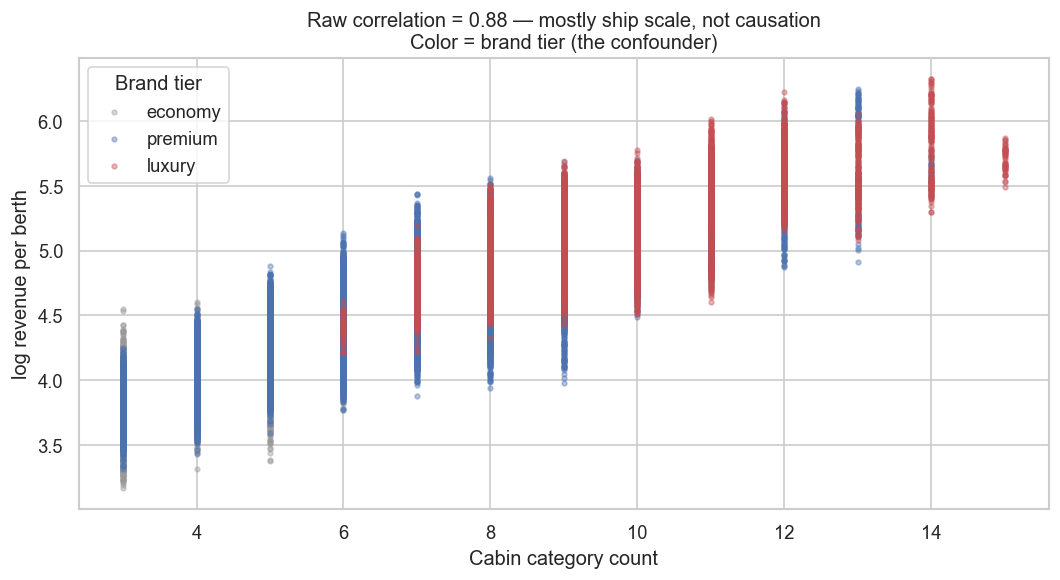

Raw correlation: 0.883  |  True causal β per category (DGP): 0.06


In [8]:
corr = panel["cabin_category_count"].corr(panel["log_revenue_per_berth"])
fig, ax = plt.subplots(figsize=(9, 5))
for tier, col in zip(["economy","premium","luxury"], ["#999999","#4C72B0","#C44E52"]):
    sub = panel[panel["brand_tier"] == tier]
    ax.scatter(sub["cabin_category_count"], sub["log_revenue_per_berth"],
               s=8, alpha=0.4, color=col, label=tier)
ax.set_xlabel("Cabin category count"); ax.set_ylabel("log revenue per berth")
ax.set_title(f"Raw correlation = {corr:.2f} — mostly ship scale, not causation\nColor = brand tier (the confounder)")
ax.legend(title="Brand tier")
plt.tight_layout(); plt.savefig(OUT_DIR/"00_raw_correlation.png", bbox_inches="tight"); plt.show()
print(f"Raw correlation: {corr:.3f}  |  True causal β per category (DGP): 0.06")